In [35]:
import pandas as pd
from prophet import Prophet
from datetime import date
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from scipy.stats.mstats import winsorize

In [13]:
client = ModoEnergyAPIClient(cache_requests=True)

16:15:26 - cmdstanpy - INFO - Chain [1] start processing
16:15:26 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
start = date(2022, 9, 11)
end = date(2026, 5, 31)

In [14]:
prices = client.get_ercot_prices(date_from=start, date_to=end)

Fetching pages : 0page [00:00, ?page/s]

Retrying <unknown> in 2 seconds as it raised HTTPError: 403 Client Error: Forbidden for url: https://api.modoenergy.com/pub/v1/us/ercot/dam/historical-prices?date_from=2022-09-11&date_to=2026-05-31&limit=10000&offset=50000.
Retrying <unknown> in 4 seconds as it raised HTTPError: 403 Client Error: Forbidden for url: https://api.modoenergy.com/pub/v1/us/ercot/dam/historical-prices?date_from=2022-09-11&date_to=2026-05-31&limit=10000&offset=50000.
Retrying <unknown> in 2 seconds as it raised HTTPError: 403 Client Error: Forbidden for url: https://api.modoenergy.com/pub/v1/us/ercot/dam/historical-prices?date_from=2022-09-11&date_to=2026-05-31&limit=10000&offset=100000.
Retrying <unknown> in 4 seconds as it raised HTTPError: 403 Client Error: Forbidden for url: https://api.modoenergy.com/pub/v1/us/ercot/dam/historical-prices?date_from=2022-09-11&date_to=2026-05-31&limit=10000&offset=100000.
Retrying <unknown> in 8 seconds as it raised HTTPError: 403 Client Error: Forbidden for url: https://a

In [33]:
hub_prices = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
]

In [36]:
hub_prices_winsorized = pd.DataFrame(
    {hub_prices.name: winsorize(hub_prices, limits=[None, 0.01])},
    index=hub_prices.index,
)

In [38]:
arbitrage_opportunity = (
    hub_prices_winsorized.resample("D")
    .agg(lambda d: max(d[d.index.hour == 19].item() - d[d.index.hour == 12].item(), 0))
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
)

<Axes: xlabel='deliveryDate'>

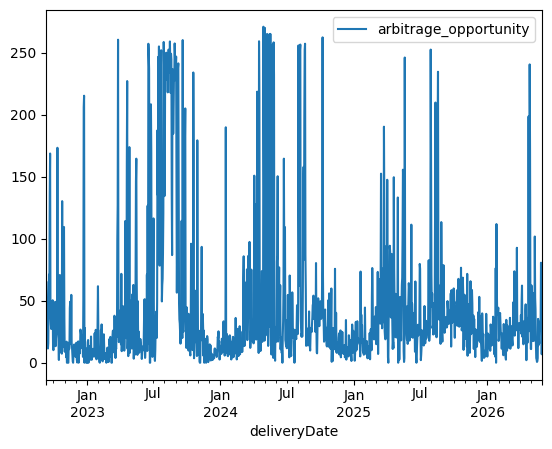

In [45]:
arbitrage_opportunity.plot()

In [40]:
prophet_data = arbitrage_opportunity.reset_index().rename(
    columns={"deliveryDate": "ds", "arbitrage_opportunity": "y"}
)

In [ ]:
model = Prophet(mcmc_samples=300)
model.add_regressor()
model.fit(prophet_data)

TypeError: Prophet.__init__() got an unexpected keyword argument 'show_console'

In [ ]:
future = model.make_future_dataframe(periods=365)


In [ ]:
forecast = model.predict(future)

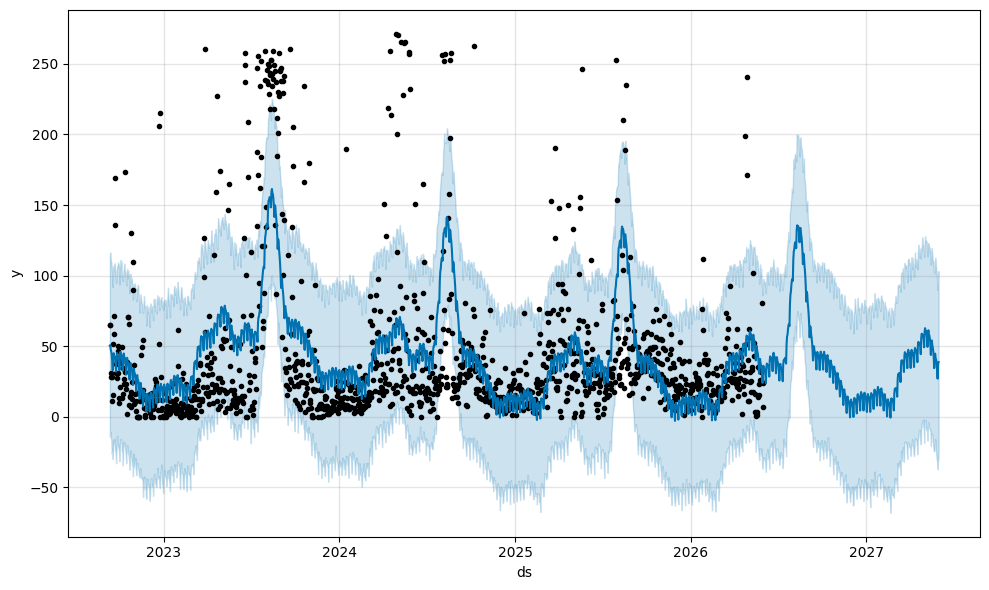

In [ ]:
fig1 = model.plot(forecast)


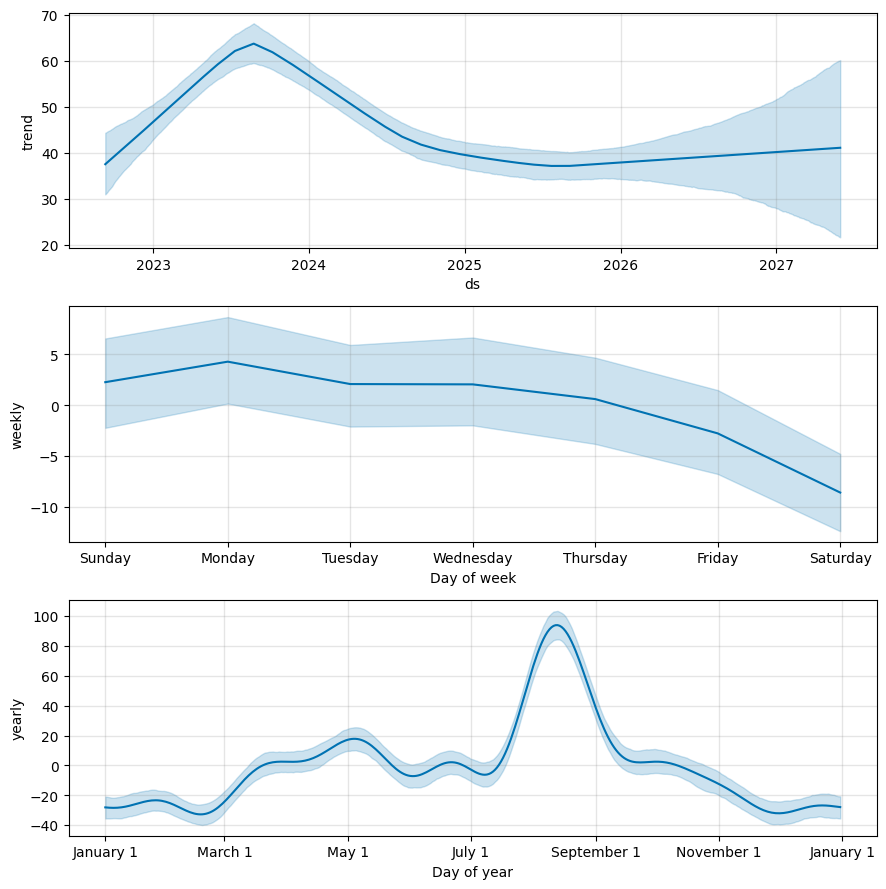

In [53]:
fig2 = m.plot_components(forecast)
